## setup

In [2]:
import pandas as pd 
import textdescriptives as td
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

!python -m spacy download en_core_web_md
nlp = spacy.load('en_core_web_md')  

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 28.6 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')


In [ ]:
# df_inter = pd.read_csv(r'/work/PENPAL/PENPAL_analysis/data/TEXT/interim/interaction_level_stories_filtered.csv')
df_full = pd.read_csv('/work/PENPAL/PENPAL_analysis/data/TEXT/interim/stories_full_text_filtered.csv')

In [7]:
df_full

,conversation_id,full_user,full_ai,language,client_id,workshop_id,timestamp,full_story
0,conv_006cb479-ccd3-40d1-83fb-4b614573f636,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",NaN,NaN,NaN,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...
1,conv_06d092f9-8297-41db-8af0-820f4e274fc2,This is the story of. Something in the shadows...,"a small, seaside town, hidden away from the re...",NaN,NaN,NaN,2025-10-21 11:36:14.377000+00:00,"This is the story of. a small, seaside town, h..."
2,conv_07ec1a21-00a8-494b-9747-ef2f719abd5a,This is the story of. She looked at the dark s...,a lighthouse keeper who forgot how to sleep.\n...,NaN,NaN,NaN,2025-11-11 16:09:45.732000+00:00,This is the story of. a lighthouse keeper who ...
3,conv_09d881cc-f751-4c13-99b4-1c61d241aed5,"This is the story of\n\nthe wizard Lizard, who...","One day, while wandering through the Enchanted...",NaN,NaN,NaN,2025-10-16 13:24:27.685000+00:00,"This is the story of\n\nthe wizard Lizard, who..."
4,conv_0b515949-4de8-486e-be19-8654481a44cc,This is the story of.,a young girl named Sophia who lived in a small...,NaN,NaN,NaN,2025-11-06 13:13:43.031000+00:00,This is the story of. a young girl named Sophi...
...,...,...,...,...,...,...,...,...
58,conv_e335739c-0072-4945-8fe4-457a04c0997b,"This is the story of\n\nOnce upon a time, ther...","to the diamond mine, their joyful voices echoi...",NaN,NaN,NaN,2025-11-11 17:17:20.655000+00:00,"This is the story of\n\nOnce upon a time, ther..."
59,conv_e4cddf1d-da8c-42d7-8e64-21bbe9af1362,Child. The child was a small child. And was ve...,Let's simplify and dive into the story:\n\nThi...,NaN,NaN,NaN,2025-10-22 16:30:06.546000+00:00,Child. The child was a small child. And was ve...
60,conv_f1cbc05f-72fe-49cb-b0fd-3c97f02e3c09,This is the story of. Twice at one's reflectio...,"...a young woman named Emma, who lived in a sm...",NaN,NaN,NaN,2025-10-15 12:59:40.218000+00:00,This is the story of. ...a young woman named E...
61,conv_faa5b6a6-2a73-4e17-874a-303a86b78e65,"This is the story of\n\nA tuna, named Big Tuna...","Big Tuna, or Jim as his mother called him, was...",NaN,NaN,NaN,2025-10-10 06:55:23.828000+00:00,"This is the story of\n\nA tuna, named Big Tuna..."


## compute surface metrics

In [9]:
td.get_valid_metrics()

{'all',
 'coherence',
 'dependency_distance',
 'descriptive_stats',
 'information_theory',
 'pos_proportions',
 'quality',
 'readability'}

In [20]:
def get_descriptive_metrics_dual_long(
        df: pd.DataFrame,
        user_col: str = "full_user",
        ai_col: str = "full_ai",
        spacy_mdl: str = "en_core_web_md",
        batch_size: int = 10,
        n_process: int = 5):

    import spacy
    import textdescriptives as td
    import pandas as pd

    print(f"[INFO:] Loading spaCy model '{spacy_mdl}'...")
    nlp = spacy.load(spacy_mdl)
    nlp.add_pipe("textdescriptives/all")

    # ----- USER -----
    print(f"[INFO:] Extracting USER metrics...")
    docs_user = nlp.pipe(df[user_col], batch_size=batch_size, n_process=n_process)
    user_metrics = td.extract_df(docs_user, include_text=True)
    user_metrics.index = df.index
    user_metrics["type"] = "user"
    if "conversation_id" in df.columns:
        user_metrics["conversation_id"] = df["conversation_id"]

    # ----- AI -----
    print(f"[INFO:] Extracting AI metrics...")
    docs_ai = nlp.pipe(df[ai_col], batch_size=batch_size, n_process=n_process)
    ai_metrics = td.extract_df(docs_ai, include_text=True)
    ai_metrics.index = df.index
    ai_metrics["type"] = "ai"
    if "conversation_id" in df.columns:
        ai_metrics["conversation_id"] = df["conversation_id"]

    # ----- STACK LONG -----
    print("[INFO:] Combining metrics (long format)...")
    metrics_long = pd.concat([user_metrics, ai_metrics], axis=0)

    return metrics_long


In [21]:
df_metrics_long = get_descriptive_metrics_dual_long(
    df=df_full,
    user_col="full_user",
    ai_col="full_ai"
)

[INFO:] Loading spaCy model 'en_core_web_md'...
[INFO:] Extracting USER metrics...
[INFO:] Extracting AI metrics...
[INFO:] Combining metrics (long format)...


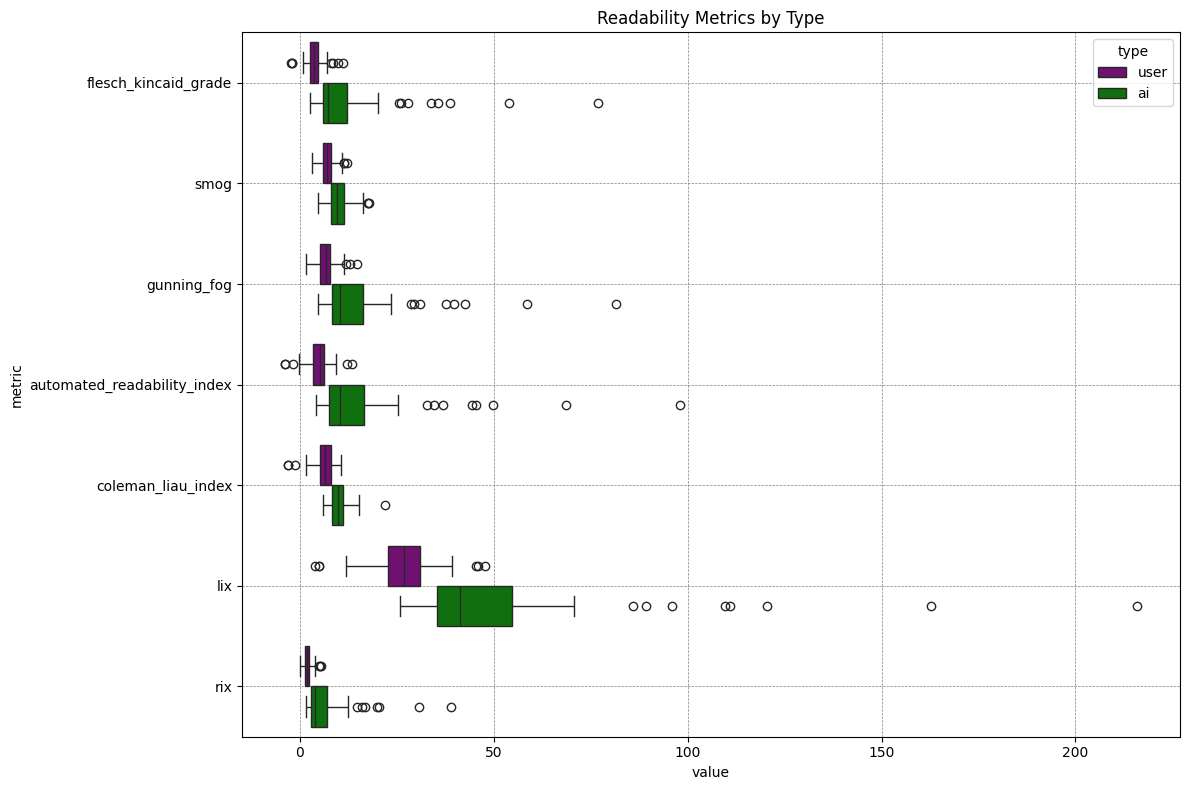

In [26]:
readability = ['flesch_kincaid_grade', 'smog',
       'gunning_fog', 'automated_readability_index', 'coleman_liau_index',
       'lix', 'rix']

df_long = df_metrics_long.melt(id_vars='type', value_vars=readability, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # readability metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Readability Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


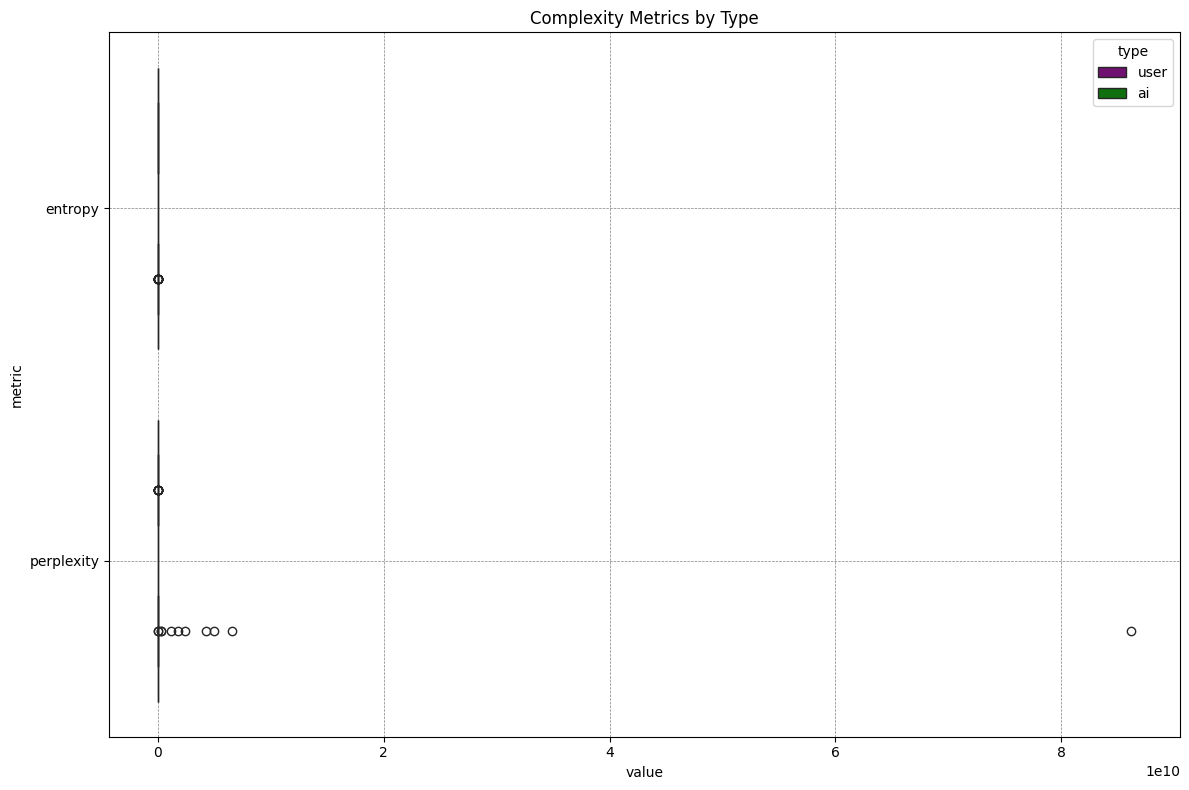

In [ ]:
complexity = ['entropy', 'perplexity']
df_long = df_metrics_long.melt(id_vars='type', value_vars=complexity, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)


plt.title('Complexity Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()


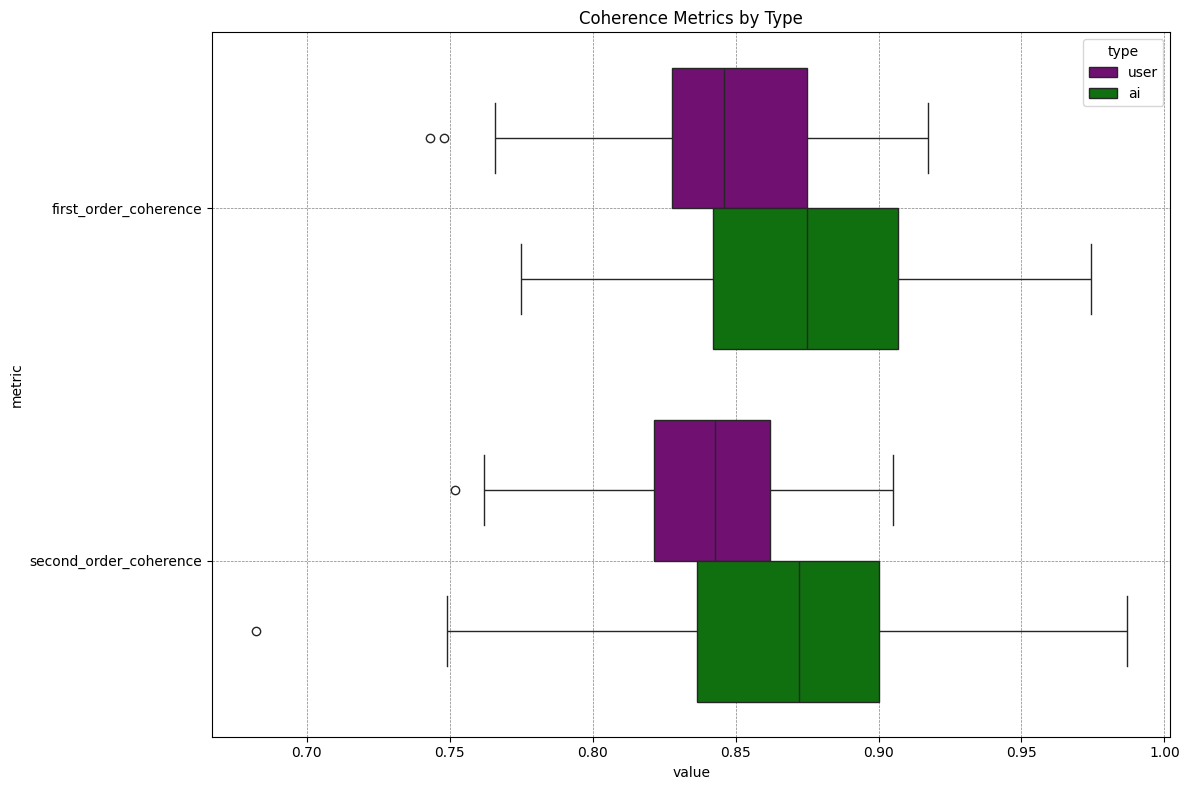

In [42]:
coherence = ['first_order_coherence', 'second_order_coherence']
df_long = df_metrics_long.melt(id_vars='type', value_vars=coherence, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Coherence Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

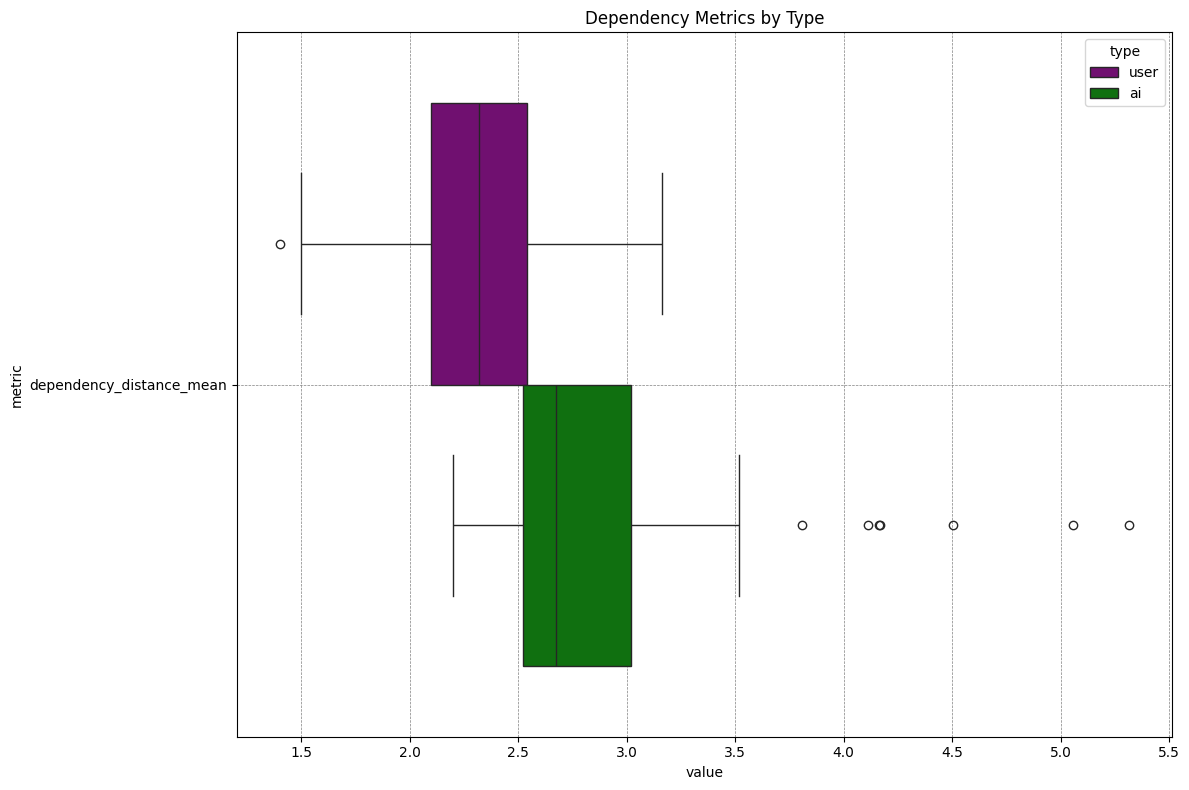

In [44]:
dependency = ['dependency_distance_mean']
df_long = df_metrics_long.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

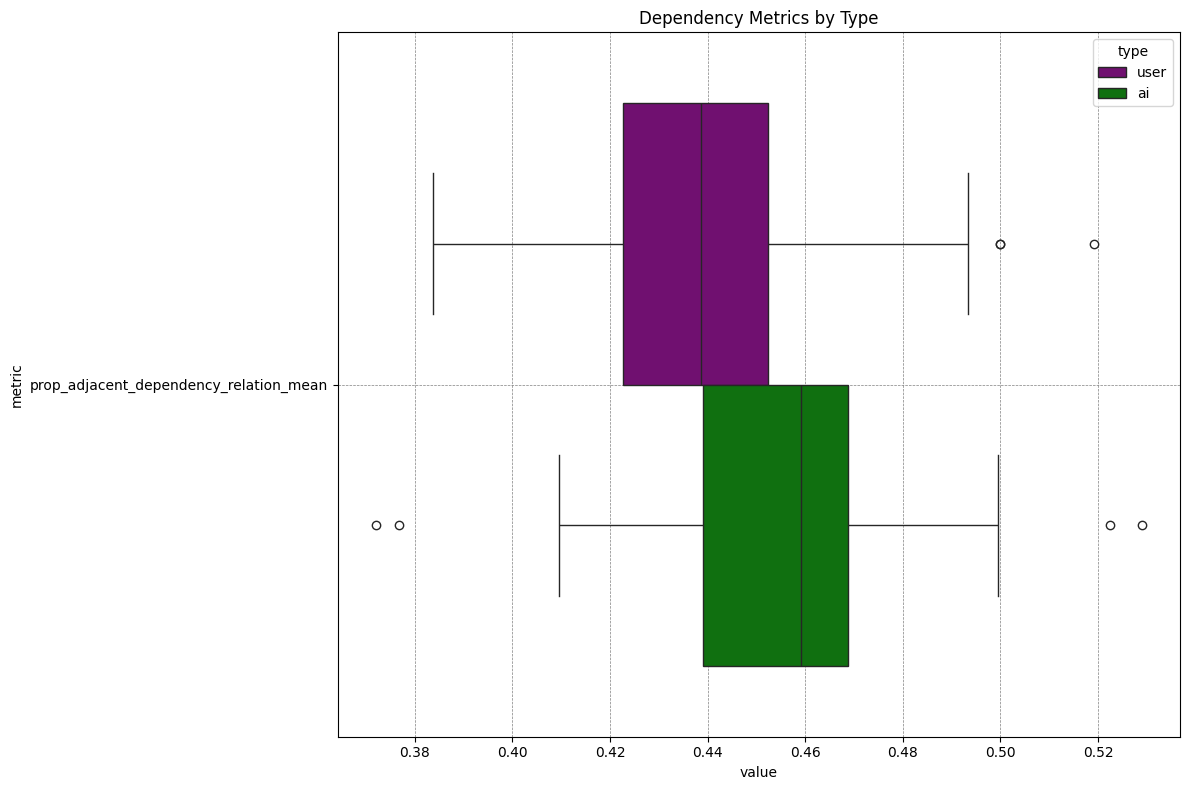

In [45]:
dependency = ['prop_adjacent_dependency_relation_mean']
df_long = df_metrics_long.melt(id_vars='type', value_vars=dependency, var_name='metric', value_name='value')

plt.figure(figsize=(12, 8))
sns.boxplot(
    data=df_long,
    y='metric',        # complexity metric on the y-axis
    x='value',         # value on the x-axis
    hue='type',        # group by type
    palette=['purple', 'green'],
    orient='h'         # horizontal orientation
)
plt.title('Dependency Metrics by Type')
plt.tight_layout()
plt.grid(color='grey', linestyle='--', linewidth=0.5)
plt.show()

### Overview

In [47]:
# df = pd.read_parquet('metrics/surface_metrics.parquet')
df = df_metrics_long.copy()

In [46]:
pos_names = {
'ADJ': 'adjective',
'ADP': 'adposition',
'ADV': 'adverb',
'AUX': 'auxiliary',
'CCONJ': 'coordinating conjunction',
'DET': 'determiner',
'INTJ': 'interjection',
'NOUN': 'noun',
'NUM': 'numeral',
'PART': 'particle',
'PRON': 'pronoun',
'PROPN': 'proper noun',
'PUNCT': 'punctuation',
'SCONJ': 'subordinating conjunction',
'SYM': 'symbol',
'VERB': 'verb',
'X': 'other',
}

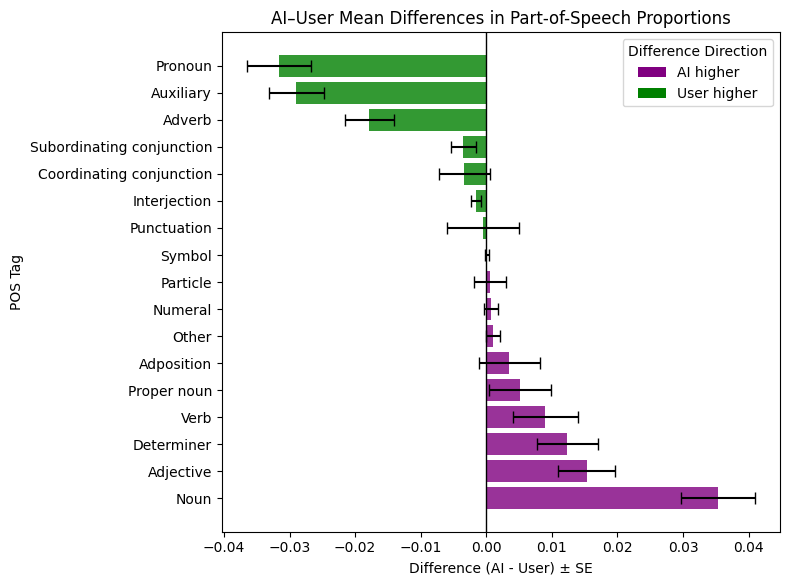

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

metrics = [col for col in df.columns if col.startswith('pos_')]

# Compute group stats
group_means = df.groupby('type')[metrics].mean().T
group_sds = df.groupby('type')[metrics].std().T
group_ns = df['type'].value_counts()

# Standard error of the difference: sqrt(s1²/n1 + s2²/n2)
se_diff = np.sqrt(
    (group_sds['ai']**2 / group_ns['ai']) +
    (group_sds['user']**2 / group_ns['user'])
)

# Difference in means
group_means['diff'] = group_means['ai'] - group_means['user']
group_means['se_diff'] = se_diff

# Sort for display
subset = group_means.sort_values('diff', ascending=False)
subset = subset.rename(index = lambda col: pos_names.get(col.split('_')[-1], col).capitalize())

# --- Plot ---
plt.figure(figsize=(8, max(4, len(subset)*0.35)))
colors = subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')


plt.barh(
    subset.index,
    subset['diff'],
    xerr=subset['se_diff'],
    color=colors,
    # ecolor=colors,          # match bar color
    capsize=4,
    alpha=0.8
)

plt.axvline(0, color='black', linewidth=1)
plt.title("AI–User Mean Differences in Part-of-Speech Proportions")
plt.xlabel("Difference (AI - User) ± SE")
plt.ylabel("POS Tag")

legend_elements = [
    Patch(facecolor='purple', label='AI higher'),
    Patch(facecolor='green', label='User higher')
]

plt.legend(handles=legend_elements, title="Difference Direction")

plt.tight_layout()
plt.show()


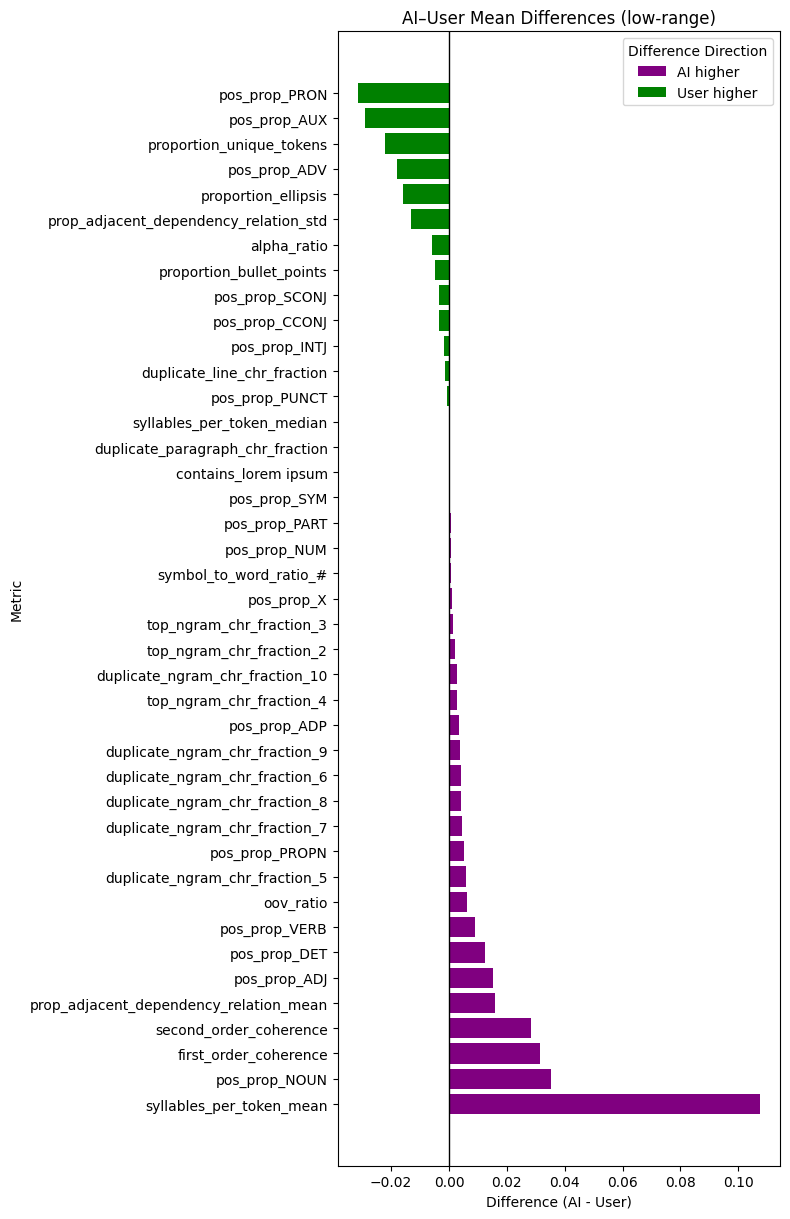

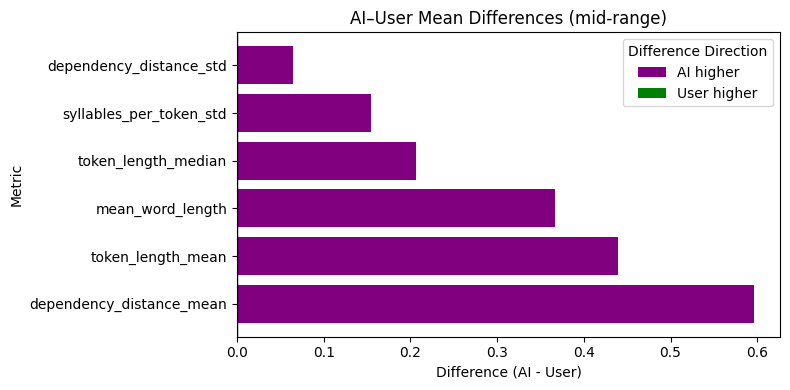

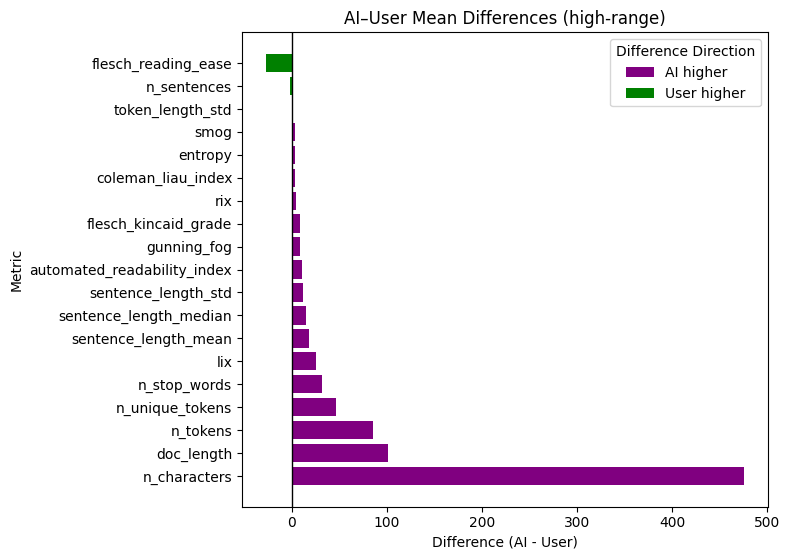

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Setup ---
df_numeric = df.select_dtypes('number')
metrics = [col for col in df_numeric.columns if col != 'per_word_perplexity' and col != 'perplexity']

# Compute mean per type
group_means = df.groupby('type')[metrics].mean().T
group_means['diff'] = group_means['ai'] - group_means['user']

# Compute ranges for grouping
min_vals = df_numeric.min()
max_vals = df_numeric.max()
ranges = max_vals - min_vals

# Define thresholds (tune if needed)
low_thr, mid_thr = 1, 10  # <1 small fractions, 1–10 mid, >10 high-range metrics

# Assign each metric to a scale group
scale_group = pd.cut(ranges, 
                     bins=[-np.inf, low_thr, mid_thr, np.inf], 
                     labels=['low-range', 'mid-range', 'high-range'])

group_means['scale_group'] = scale_group

# --- Plot each scale group separately ---
for group in ['low-range', 'mid-range', 'high-range']:
    subset = group_means[group_means['scale_group'] == group].sort_values('diff', ascending=False)
    if subset.empty:
        continue

    plt.figure(figsize=(8, max(4, len(subset)*0.3)))
    plt.barh(
        subset.index,
        subset['diff'],
        color=subset['diff'].apply(lambda x: 'purple' if x > 0 else 'green')
    )
    plt.axvline(0, color='black', linewidth=1)
    plt.title(f"AI–User Mean Differences ({group})")
    plt.xlabel("Difference (AI - User)")
    plt.ylabel("Metric")
        
    legend_elements = [
        Patch(facecolor='purple', label='AI higher'),
        Patch(facecolor='green', label='User higher')
    ]

    plt.legend(handles=legend_elements, title="Difference Direction")
    plt.tight_layout()
    plt.show()


In [76]:
for i in range(0, 100, 5): 
    print(f"Quantile: {i/100}:", f"{round(df.loc[:, 'perplexity'].quantile(q=i/100),3):2_}")

Quantile: 0.0: 1.2
Quantile: 0.05: 3.925
Quantile: 0.1: 18.785
Quantile: 0.15: 132.634
Quantile: 0.2: 327.145
Quantile: 0.25: 1_244.336
Quantile: 0.3: 1_813.794
Quantile: 0.35: 2_670.634
Quantile: 0.4: 3_337.991
Quantile: 0.45: 4_760.502
Quantile: 0.5: 5_915.849
Quantile: 0.55: 9_137.522
Quantile: 0.6: 12_614.142
Quantile: 0.65: 14_405.856
Quantile: 0.7: 21_089.13
Quantile: 0.75: 32_467.736
Quantile: 0.8: 45_395.907
Quantile: 0.85: 71_718.751
Quantile: 0.9: 1_380_113.738
Quantile: 0.95: 955_080_571.381


## z-scored

/work/PENPAL/venv/lib/python3.12/site-packages/pandas/core/apply.py:1081: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  results[i] = self.func(v, *self.args, **self.kwargs)


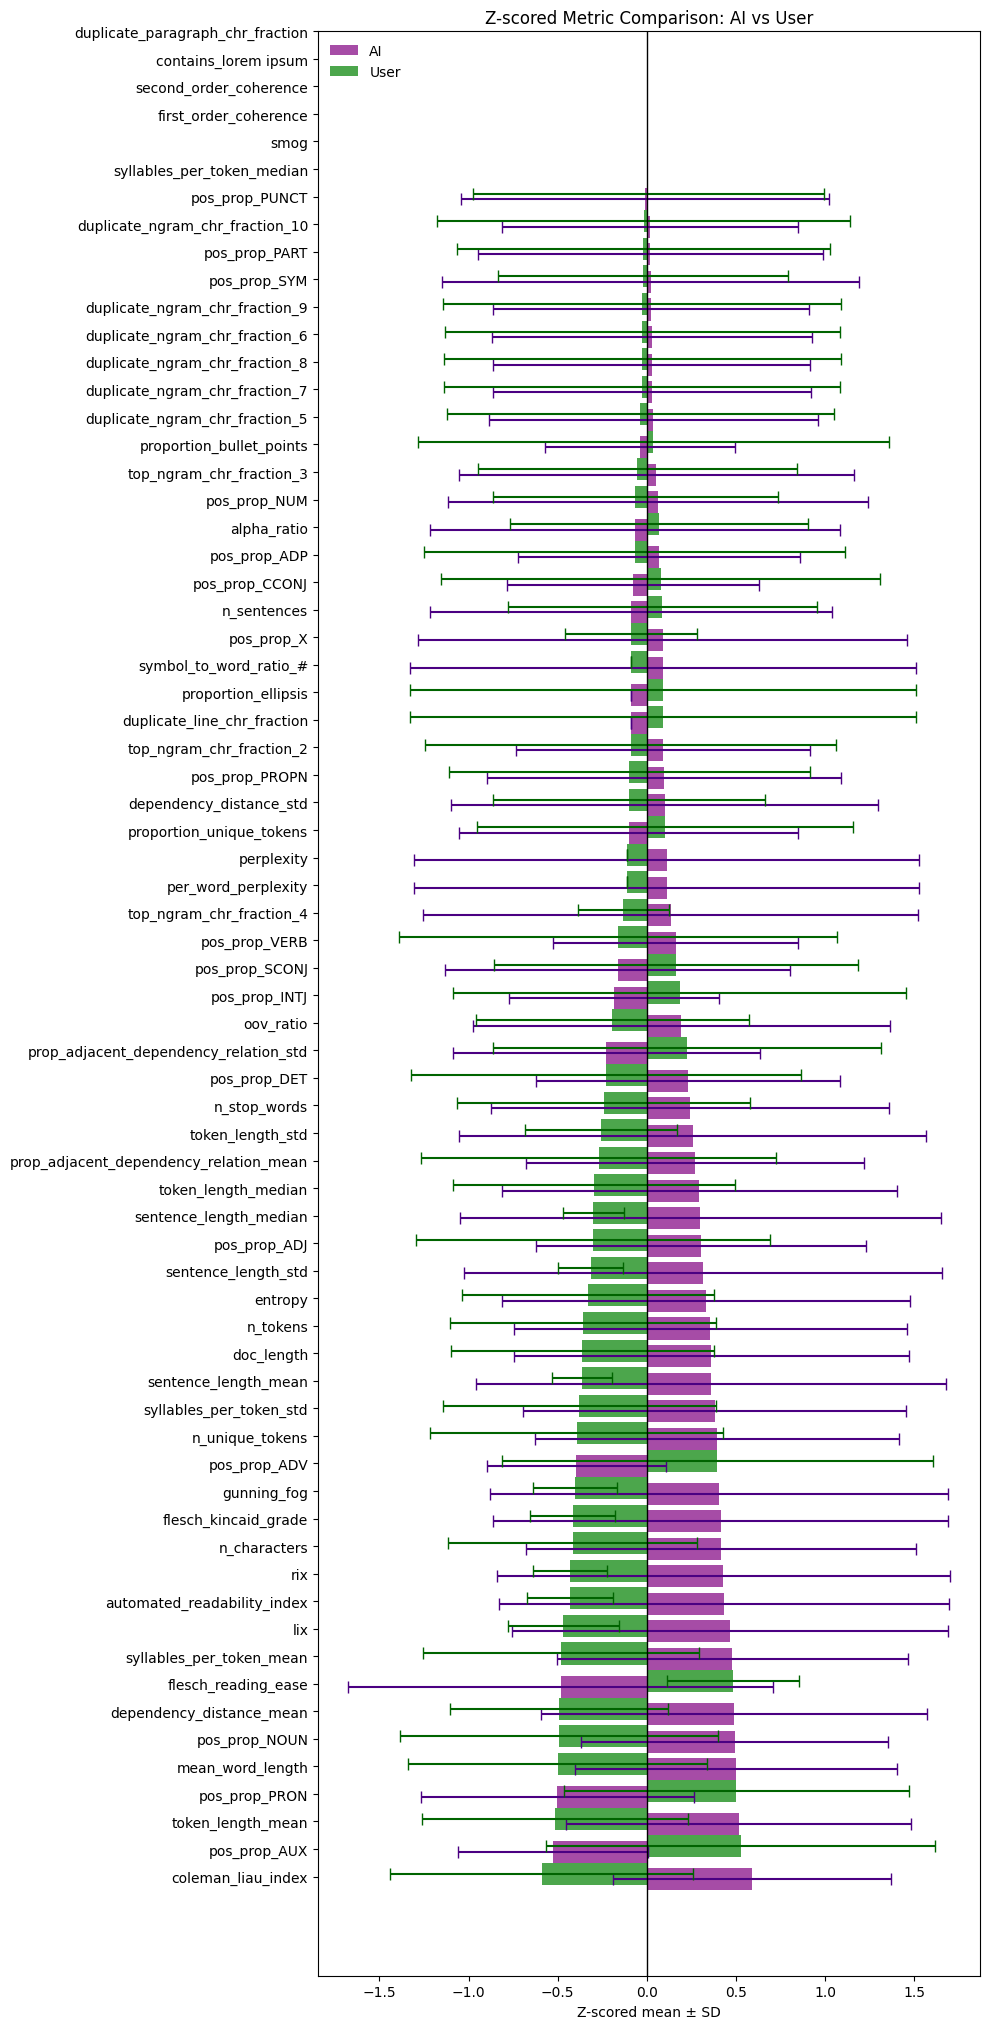

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

# --- Z-score numeric metrics ---
df_numeric = df.select_dtypes('number')
metrics = df_numeric.columns
df_z = df_numeric.apply(zscore)
df_z['type'] = df['type']

# --- Compute means & sds ---
group_means = df_z.groupby('type')[metrics].mean().T
group_sds   = df_z.groupby('type')[metrics].std().T
group_means['diff'] = group_means['ai'] - group_means['user']

# --- Sort by absolute difference ---
order = group_means['diff'].abs().sort_values(ascending=False).index
x = np.arange(len(order))
width = 0.2

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, max(5, len(metrics)*0.3)))

# AI bars with purple error bars
ax.barh(x - width/2, group_means.loc[order, 'ai'],
        xerr=group_sds.loc[order, 'ai'],
        label='AI',
        color='purple', alpha=0.7, capsize=4, ecolor='indigo')

# User bars with green error bars
ax.barh(x + width/2, group_means.loc[order, 'user'],
        xerr=group_sds.loc[order, 'user'],
        label='User',
        color='green', alpha=0.7, capsize=4, ecolor='darkgreen',)

# Cosmetic tweaks
ax.axvline(0, color='black', linewidth=1)
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("Z-scored mean ± SD")
ax.set_title("Z-scored Metric Comparison: AI vs User")
ax.legend(frameon=False, loc='best')
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd 
df_inter = pd.read_parquet('/work/PENPAL/PENPAL_analysis/data/TEXT/processed/story_embeddings_interaction_level.parquet')
df_full = pd.read_parquet('/work/PENPAL/PENPAL_analysis/data/TEXT/processed/story_embeddings_full.parquet')

In [ ]:
df_inter = df_inter[~df_inter["respondent_id"].str.startswith("test-")]

In [10]:
df

,timestamp,user,ai,combined_prompt,client_id,workshop_id,language,conversation_id,respondent_id,user_embedding,ai_embedding
3,2025-11-13 12:34:34.539000+00:00,This is the story of\n\nThere once was a young...,"with her best friend, leaving her feeling shat...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009847976267337799, 0.0016179666854441166,...","[-0.006720611359924078, 0.006121717393398285, ..."
4,2025-11-13 12:36:05.046000+00:00,who claimed they loved her. This made her hard...,to take a chance and start attending social ev...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.009516920894384384, 0.014092739671468735, ...","[-0.003943391144275665, -0.006826835218816996,..."
5,2025-11-13 12:37:38.170000+00:00,that she meet another young woman just like he...,"until one evening, when they both found themse...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.012823346070945263, 0.001509161782450974, ...","[0.0023674711119383574, 0.0010259754490107298,..."
6,2025-11-13 12:39:04.145000+00:00,as if they where destined to meet. They starte...,"developed a deep and meaningful connection, on...",NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[0.004188875202089548, 0.00921684317290783, -0...","[0.0027713251765817404, -0.007644712459295988,..."
7,2025-11-13 12:40:11.365000+00:00,time whent on their connection became more tha...,had been afraid to acknowledge the true nature...,NaN,NaN,NaN,NaN,conv_006cb479-ccd3-40d1-83fb-4b614573f636,A89X12UN9Y1T,"[-0.001402832567691803, 0.023314062505960464, ...","[-0.010389024391770363, -0.004656300414353609,..."
...,...,...,...,...,...,...,...,...,...,...,...
458,2025-11-06 12:28:08.840000+00:00,A house. It sits above the washbasin and is gr...,"more defined, but the scene in the clearing st...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.013003706932067871, 0.00976136326789856, 0...","[0.0035752165131270885, -0.005327609833329916,..."
459,2025-11-06 12:28:26.672000+00:00,The neighbors all say that the dust will pass....,"own. But as Ezra and I stood there, the dust s...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.0008603244205005467, -0.002290817676112055...","[0.0006013151723891497, 0.004016820341348648, ..."
460,2025-11-06 12:28:45.498000+00:00,Little Bessie and I go into town the next day ...,"cow, and she’s been a faithful companion throu...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.005458412226289511, 0.015171225182712078, ...","[-0.004755269270390272, 0.002042467473074794, ..."
461,2025-11-06 12:29:06.828000+00:00,"As we ride in, we see the new pop-up shop sell...","asks. But today, there's a different kind of e...",NaN,NaN,NaN,NaN,conv_fe95c724-f91e-4a17-8400-9bfbdf9218ec,S8K59R2QA4CS,"[-0.007142434362322092, 0.0070573207922279835,...","[0.005576384719461203, -0.001296370755881071, ..."


In [16]:
for _, row in df_full.iterrows():
    print(row['full_story'])

This is the story of

There once was a young woman who had trust issues. She had been betrayed by her ex-boyfriend who cheated on her with her best friend, leaving her feeling shattered and vulnerable. The experience had made her wary of opening up to anyone new, and she found herself constantly questioning the motives of those who claimed they loved her. This made her hard to reach but also very lonely. She was lonely like this for many years but finally she decided to take a chance and start attending social events again, hoping to meet someone who could help her heal and learn to trust once more. It was at one of these events, that she meet another young woman just like her self who also had trust issues. They meet many times without ever talking much or becoming close. until one evening, when they both found themselves sitting alone at a small café, each lost in their own thoughts. The atmosphere was quiet and intimate, and somehow, it seemed as if they where destined to meet. They